In [1]:
import math
import os
import numpy as np
import tifffile as tiff
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import umap.umap_ as umap
from transformers import AutoModel, AutoVideoProcessor

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: False


In [10]:
hf_model_name = "facebook/vjepa2-vitg-fpc64-384"
TIF_FILE = "output/merged_from_annotations.tif"
GT_CLASSES_FILE = "output/merged_from_annotations_classes.tif"
TARGET_CLASS = 224  # hard-coded class to segment
N_PRIORS = 5000   # total priors: 50% target / 50% non-target
RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")
print(f"HuggingFace model: {hf_model_name}")
print(f"GT classes TIFF: {GT_CLASSES_FILE}")
print(f"Target class: {TARGET_CLASS}")
print(f"Total priors: {N_PRIORS}")

Using device: cpu
HuggingFace model: facebook/vjepa2-vitg-fpc64-384
GT classes TIFF: output/merged_from_annotations_classes.tif
Target class: 224
Total priors: 5000


In [3]:
# Load the 3D volume
tif = tiff.TiffFile(TIF_FILE)
volume = tif.asarray()
metadata = tif.pages[0].tags

# Keep only slices that contain information (not fully uniform)
v = volume.astype(np.float32)

slice_min = v.min(axis=(1, 2))
slice_max = v.max(axis=(1, 2))
slice_std = v.std(axis=(1, 2))

range_eps = 1e-6
std_eps = 1e-6

valid_indices = np.where(((slice_max - slice_min) > range_eps) & (slice_std > std_eps))[0]
volume_filtered = volume[valid_indices]  # original slice values are unchanged

print(f"Kept {len(valid_indices)}/{volume.shape[0]} informative slices")
print(f"Filtered volume shape: {volume_filtered.shape}")

Kept 72/200 informative slices
Filtered volume shape: (72, 512, 512)


In [4]:
# Official HuggingFace initialization
model_hf = AutoModel.from_pretrained(hf_model_name).to(DEVICE).eval()
hf_transform = AutoVideoProcessor.from_pretrained(hf_model_name)

img_size = hf_transform.crop_size["height"]
frames_per_clip = model_hf.config.frames_per_clip
patch_size = model_hf.config.patch_size
tubelet_size = model_hf.config.tubelet_size

print("Loaded HuggingFace model + video processor")
print(f"img_size={img_size}, frames_per_clip={frames_per_clip}, patch_size={patch_size}, tubelet_size={tubelet_size}")

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

Loaded HuggingFace model + video processor
img_size=384, frames_per_clip=64, patch_size=16, tubelet_size=2


In [5]:
save_path = "output/volume_filtered_frame_patch_features.pt"
os.makedirs("output", exist_ok=True)

num_frames = volume_filtered.shape[0]
recompute = True

if os.path.exists(save_path):
    frame_patch_features = torch.load(save_path, map_location="cpu")
    if frame_patch_features.shape[0] == num_frames:
        recompute = False
        print(f"Loaded cached features from: {save_path}")
        print(f"Patch features per slice: {tuple(frame_patch_features.shape)}")
    else:
        print(
            f"Cached features shape mismatch "
            f"(got {frame_patch_features.shape[0]} slices, expected {num_frames}). Recomputing..."
        )

if recompute:
    video_rgb = np.repeat(volume_filtered[..., None], 3, axis=-1).astype(np.uint8)
    print(f"RGB video shape: {video_rgb.shape}")

    num_clips = math.ceil(num_frames / frames_per_clip)
    pad_frames = num_clips * frames_per_clip - num_frames
    if pad_frames > 0:
        pad = np.repeat(video_rgb[-1][None], pad_frames, axis=0)
        video_rgb = np.concatenate([video_rgb, pad], axis=0)

    clips = video_rgb.reshape(
        num_clips, frames_per_clip, video_rgb.shape[1], video_rgb.shape[2], 3
    )
    inputs = hf_transform([clip for clip in clips], return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    print(f"Preprocessed tensor shape: {tuple(inputs['pixel_values_videos'].shape)}")

    with torch.no_grad():
        out_patch_features_hf = model_hf.get_vision_features(**inputs)

    B, N_tokens, D = out_patch_features_hf.shape
    h_p = img_size // patch_size
    w_p = img_size // patch_size
    t_tokens = N_tokens // (h_p * w_p)

    patch_tokens = out_patch_features_hf.view(B, t_tokens, h_p, w_p, D).cpu()
    all_t_tokens = patch_tokens.reshape(B * t_tokens, h_p, w_p, D)
    frame_patch_features = all_t_tokens.repeat_interleave(tubelet_size, dim=0)[:num_frames]

    print(f"Raw token features: {tuple(out_patch_features_hf.shape)}")
    print(f"Patch features per slice: {tuple(frame_patch_features.shape)}")

    torch.save(frame_patch_features, save_path)
    print(f"Saved features to: {save_path}")

Loaded cached features from: output/volume_filtered_frame_patch_features.pt
Patch features per slice: (72, 24, 24, 1408)


In [6]:
# Keep only the first 64 slices (drop all later slices)
n_keep = 64

if volume_filtered.shape[0] < n_keep:
    raise ValueError(f"volume_filtered has only {volume_filtered.shape[0]} slices, cannot keep {n_keep}.")

volume_filtered = volume_filtered[:n_keep]
valid_indices = valid_indices[:n_keep]

# Keep features aligned with the filtered volume (if already computed)
if "frame_patch_features" in globals():
    frame_patch_features = frame_patch_features[:n_keep]

# Optional: keep cached RGB stack aligned too
if "video_rgb" in globals():
    video_rgb = video_rgb[:n_keep]

print(f"volume_filtered shape: {volume_filtered.shape}")
print(f"valid_indices shape: {valid_indices.shape}")
if "frame_patch_features" in globals():
    print(f"frame_patch_features shape: {tuple(frame_patch_features.shape)}")

volume_filtered shape: (64, 512, 512)
valid_indices shape: (64,)
frame_patch_features shape: (64, 24, 24, 1408)


/home/jgnav/Workspace/CSIC-collaboration/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Foreground patch vectors for UMAP: (14090, 1408)
Foreground patch ratio: 0.3822
UMAP maps (patch grid): (64, 24, 24, 3)
UMAP maps (original resolution): (64, 512, 512, 3)


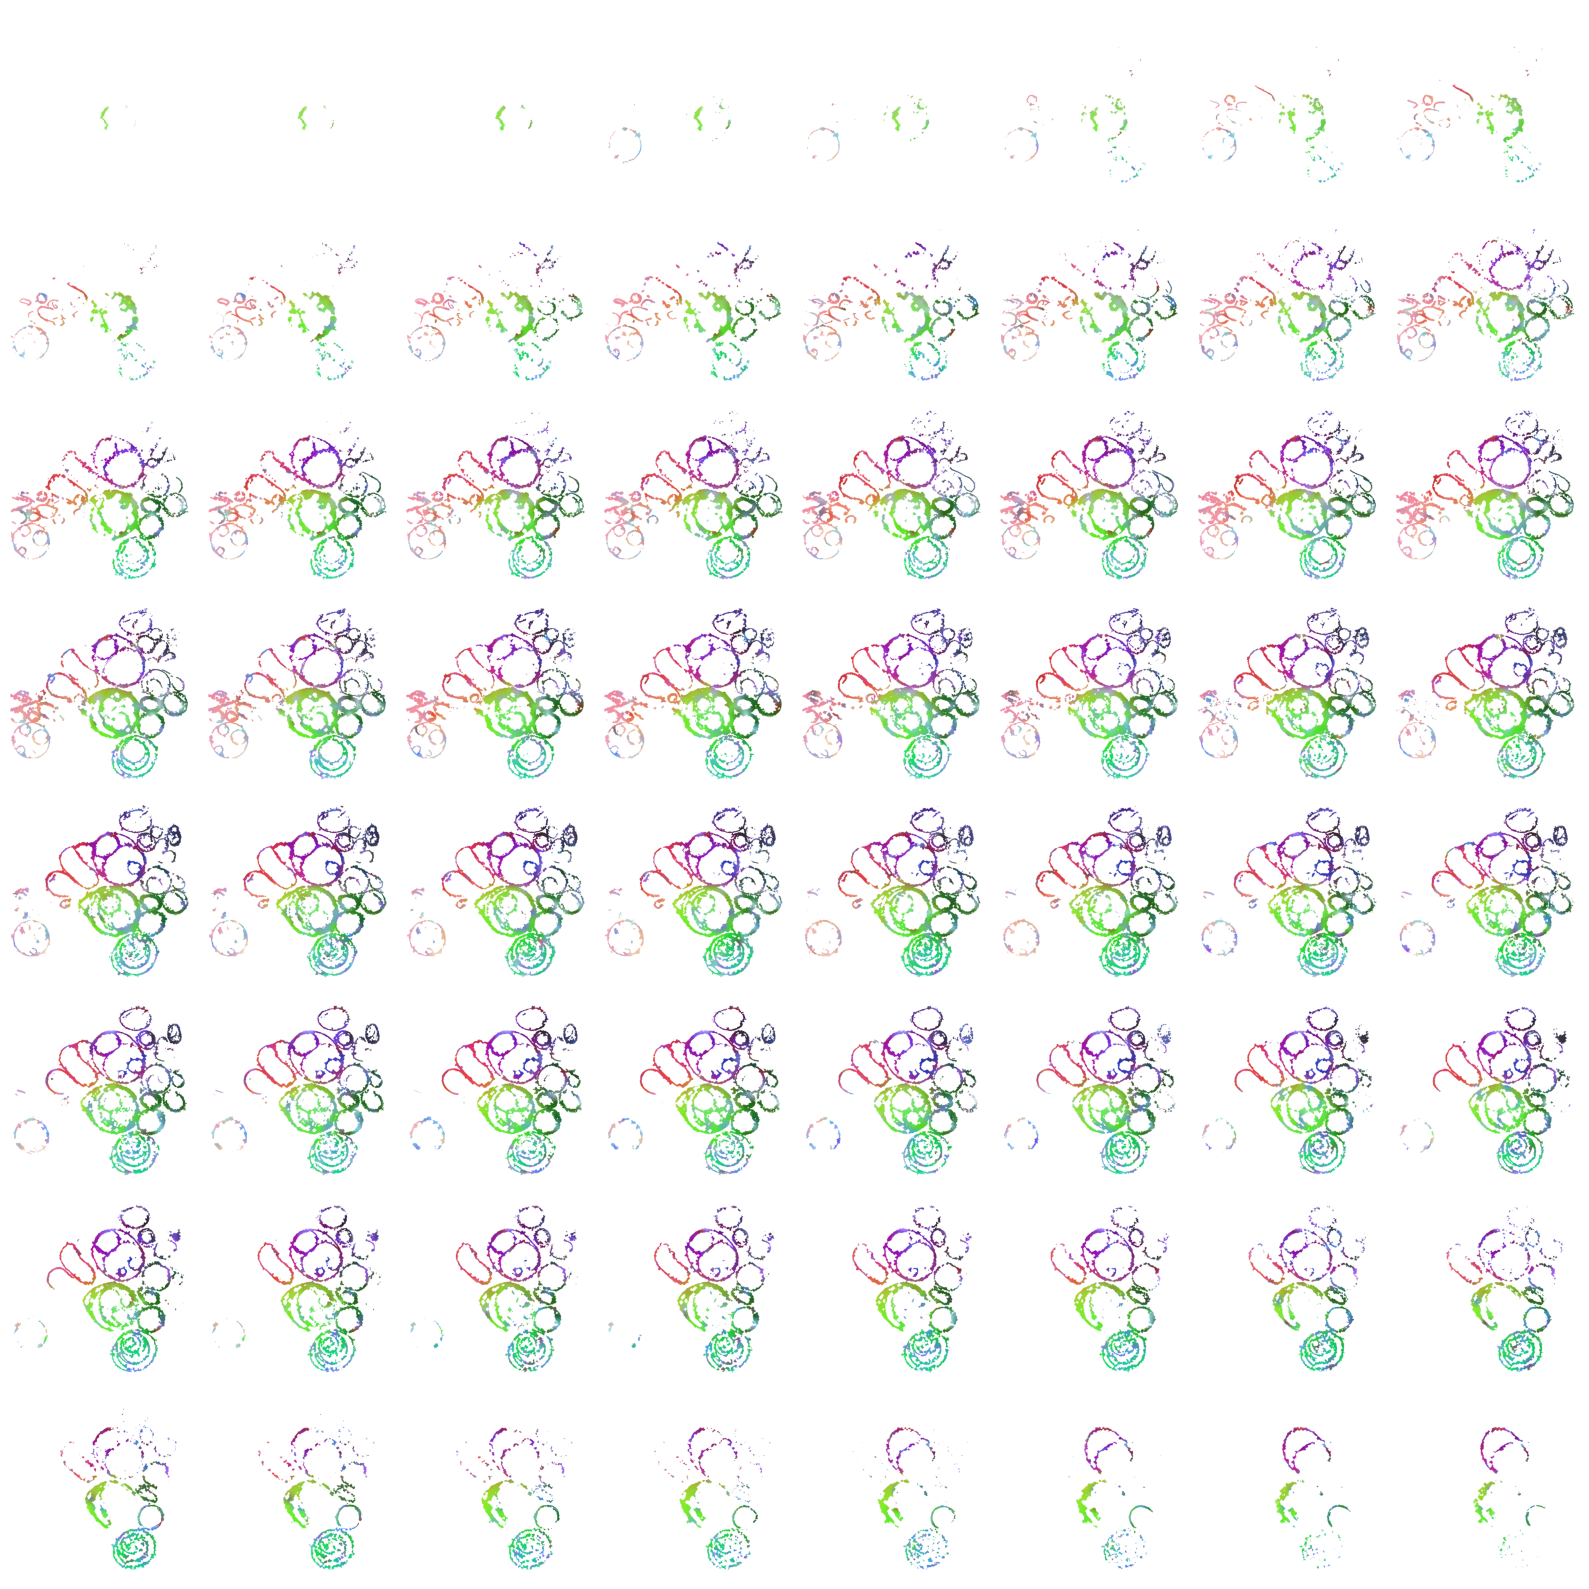

In [7]:
features_np = frame_patch_features.numpy()
n_slices, p_h, p_w, feat_dim = features_np.shape

bg = volume_filtered.max()
eps = 1e-6
volume_binary = (volume_filtered < (bg - eps)).astype(np.uint8)

binary_t = torch.from_numpy(volume_binary[:, None, :, :]).float()
patch_mask = F.adaptive_max_pool2d(binary_t, output_size=(p_h, p_w)).squeeze(1).numpy() > 0.5

flat_features = features_np.reshape(-1, feat_dim)
flat_mask = patch_mask.reshape(-1)
masked_features = flat_features[flat_mask]

reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
masked_umap = reducer.fit_transform(masked_features)
masked_umap = (masked_umap - masked_umap.mean(axis=0, keepdims=True)) / (masked_umap.std(axis=0, keepdims=True) + 1e-6)
masked_umap = 1.0 / (1.0 + np.exp(-(masked_umap / 0.75)))

flat_umap = np.ones((flat_features.shape[0], 3), dtype=np.float32)
flat_umap[flat_mask] = masked_umap

umap_maps = flat_umap.reshape(n_slices, p_h, p_w, 3)
umap_maps_t = torch.from_numpy(umap_maps).permute(0, 3, 1, 2).float()
umap_maps_up = F.interpolate(
    umap_maps_t,
    size=volume_filtered.shape[1:],
    mode="bilinear",
    align_corners=False,
).permute(0, 2, 3, 1).numpy()

umap_maps_up[volume_binary == 0] = 1.0

print(f"Foreground patch vectors for UMAP: {masked_features.shape}")
print(f"Foreground patch ratio: {flat_mask.mean():.4f}")
print(f"UMAP maps (patch grid): {umap_maps.shape}")
print(f"UMAP maps (original resolution): {umap_maps_up.shape}")

n_slices_filtered = umap_maps_up.shape[0]
n_cols = 8
n_rows = int(np.ceil(n_slices_filtered / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i in range(n_rows * n_cols):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    if i < n_slices_filtered:
        ax.imshow(np.clip(umap_maps_up[i], 0, 1))
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

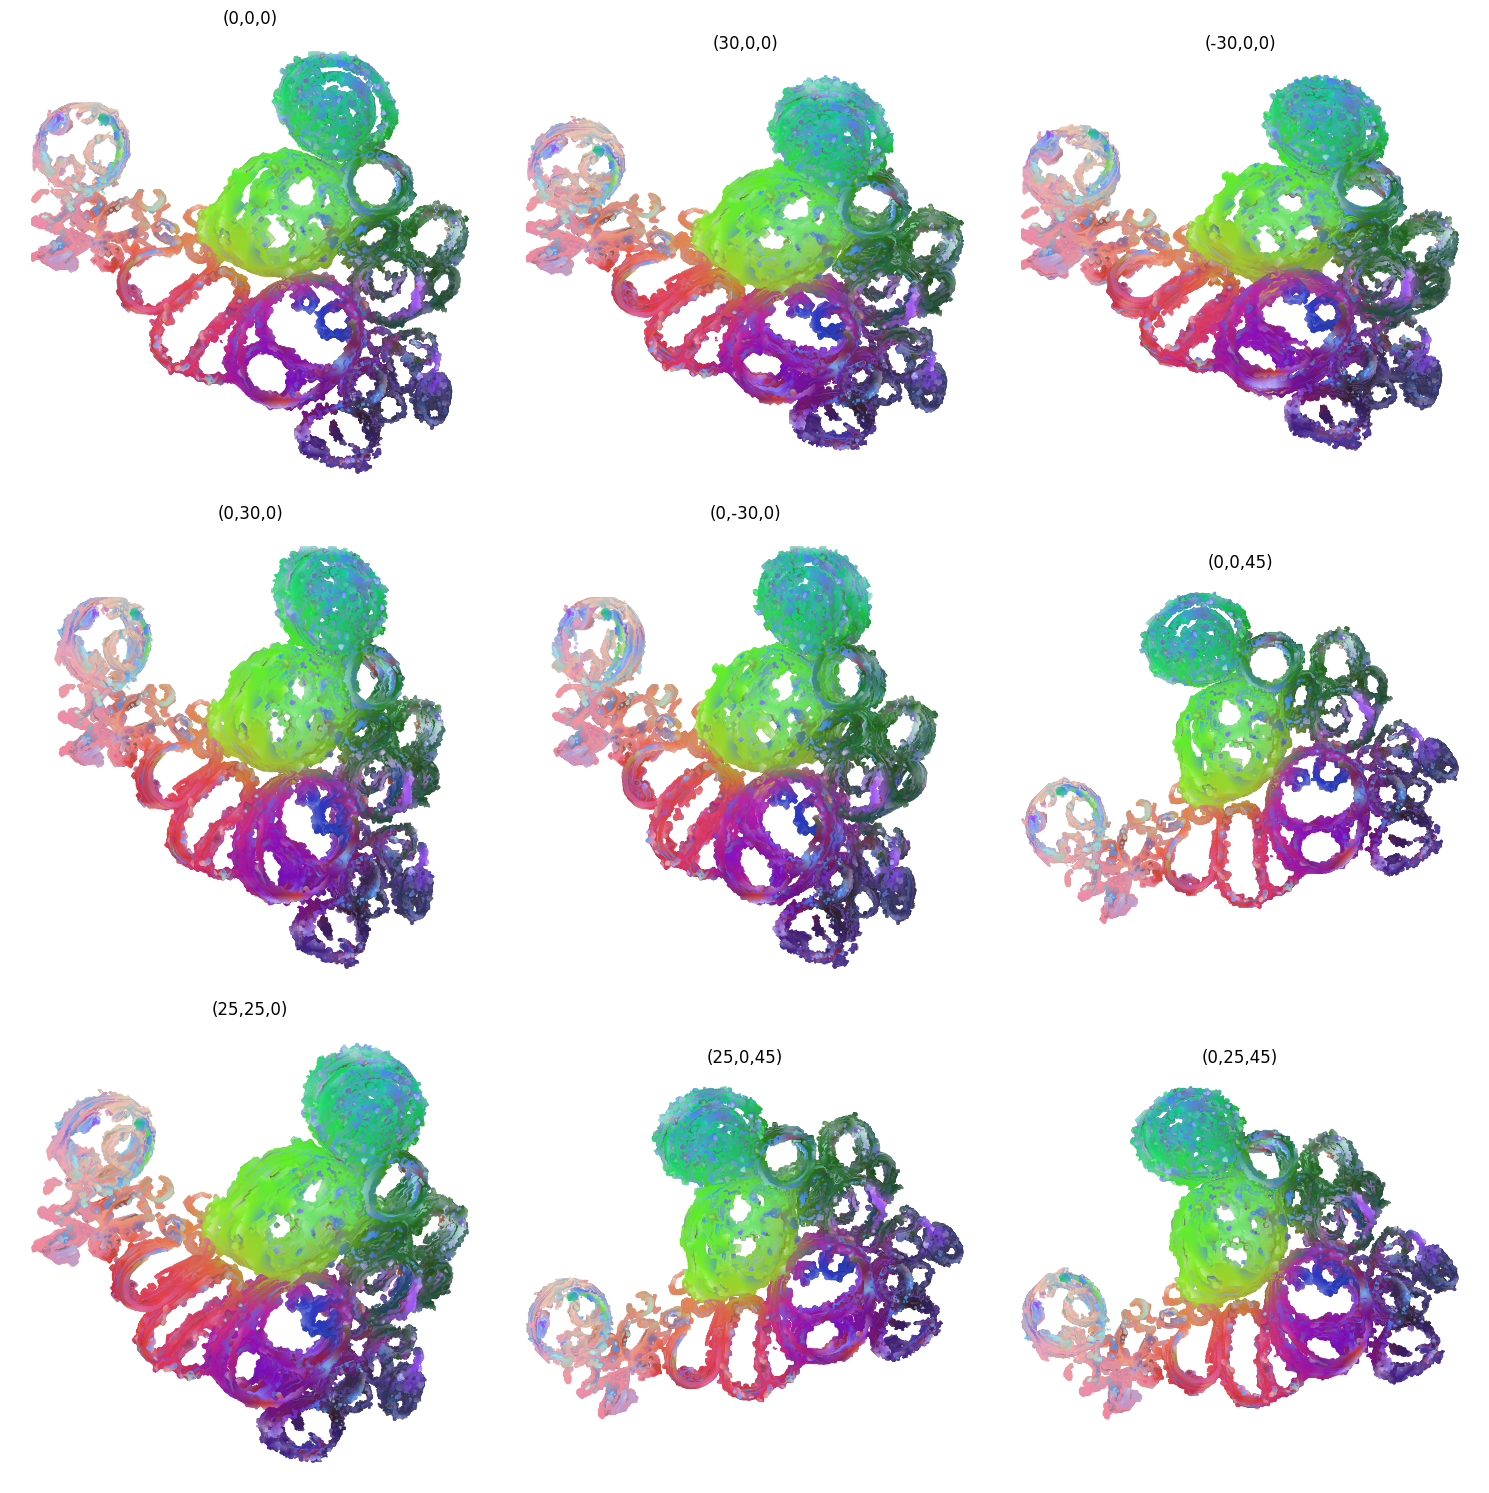

In [8]:
mask = volume_binary > 0

zf, y, x = np.where(mask)
z = valid_indices[zf]
rgb_vals = umap_maps_up[mask]

xc = (x.min() + x.max()) / 2.0
yc = (y.min() + y.max()) / 2.0
zc = (z.min() + z.max()) / 2.0

xx = x - xc
yy = y - yc
zz = z - zc

views = [
    ("(0,0,0)", 0, 0, 0),
    ("(30,0,0)", 30, 0, 0),
    ("(-30,0,0)", -30, 0, 0),
    ("(0,30,0)", 0, 30, 0),
    ("(0,-30,0)", 0, -30, 0),
    ("(0,0,45)", 0, 0, 45),
    ("(25,25,0)", 25, 25, 0),
    ("(25,0,45)", 25, 0, 45),
    ("(0,25,45)", 0, 25, 45),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15), facecolor="white")
axs = axs.ravel()

for i, (title, ax_deg, ay_deg, az_deg) in enumerate(views):
    axr = np.deg2rad(ax_deg)
    ayr = np.deg2rad(ay_deg)
    azr = np.deg2rad(az_deg)

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(axr), -np.sin(axr)],
        [0, np.sin(axr), np.cos(axr)],
    ])
    Ry = np.array([
        [np.cos(ayr), 0, np.sin(ayr)],
        [0, 1, 0],
        [-np.sin(ayr), 0, np.cos(ayr)],
    ])
    Rz = np.array([
        [np.cos(azr), -np.sin(azr), 0],
        [np.sin(azr), np.cos(azr), 0],
        [0, 0, 1],
    ])

    R = Rz @ Ry @ Rx
    rot = R @ np.vstack((xx, yy, zz))

    u = rot[0]
    v = rot[1]

    axs[i].scatter(u, v, c=rgb_vals, s=1, linewidths=0, alpha=0.95)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(title)
    axs[i].set_facecolor("white")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

# --- 1) Build foreground token matrix using ONLY masked features ---
X = masked_features.astype(np.float32)
num_tokens_fg = X.shape[0]
if num_tokens_fg < 2:
    raise ValueError("Not enough foreground tokens for normalized cut.")

# L2 normalize token descriptors
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
print(f"Foreground tokens used for Ncut: {num_tokens_fg}")

# --- 2) Full affinity matrix W (NO downsampling, NO k-NN) ---
tau = 0.0
eps_graph = 1e-5
no_binary_graph = False

A = X @ X.T  # cosine similarity because X is normalized

if no_binary_graph:
    A[A < tau] = 0.0
else:
    A = (A > tau).astype(np.float32)

# Symmetrize and keep self-links
A = np.maximum(A, A.T)
np.fill_diagonal(A, 1.0)

W = csr_matrix(A)
del A

# --- 3) Normalized Cut (2-way) with generalized eigenproblem ---
deg = np.asarray(W.sum(axis=1)).ravel() + eps_graph
D = diags(deg)
L = D - W

_, eigvecs = eigsh(L, k=2, M=D, which="SM")
second_smallest_vec = eigvecs[:, 1]

avg = float(second_smallest_vec.mean())
labels_fg = second_smallest_vec > avg
seed = int(np.argmax(np.abs(second_smallest_vec)))

if not labels_fg[seed]:
    second_smallest_vec = -second_smallest_vec
    labels_fg = np.logical_not(labels_fg)

labels_fg = labels_fg.astype(np.int8)

# Token labels on patch grid (-1 for background), fill foreground by flat_mask order
token_labels_flat = -np.ones(flat_mask.shape[0], dtype=np.int8)
token_labels_flat[flat_mask] = labels_fg
token_labels = token_labels_flat.reshape(patch_mask.shape)

# --- 4) Upscale token labels to voxel resolution ---
token_labels_t = torch.from_numpy(token_labels.astype(np.float32))[None, None]  # [1,1,S,p_h,p_w]
partition_up = F.interpolate(
    token_labels_t,
    size=volume_filtered.shape,
    mode="nearest",
).squeeze(0).squeeze(0).numpy().astype(np.int8)

partition_up[volume_binary == 0] = -1

print(f"Token partition labels shape: {token_labels.shape}")
print(f"Upscaled partition volume shape: {partition_up.shape}")
print(f"Partition counts (fg only): {(partition_up == 0).sum()} / {(partition_up == 1).sum()}")

# --- 5) Same volume representation, colored by partition ---
mask_part = partition_up >= 0
zf, y, x = np.where(mask_part)
z = valid_indices[zf]
part_vals = partition_up[mask_part]

# Two distinct colors for the two partitions
partition_colors = np.array([
    [0.10, 0.45, 1.00],
    [1.00, 0.35, 0.15],
], dtype=np.float32)
rgb_vals = partition_colors[part_vals]

xc = (x.min() + x.max()) / 2.0
yc = (y.min() + y.max()) / 2.0
zc = (z.min() + z.max()) / 2.0

xx = x - xc
yy = y - yc
zz = z - zc

views = [
    ("(0,0,0)", 0, 0, 0),
    ("(30,0,0)", 30, 0, 0),
    ("(-30,0,0)", -30, 0, 0),
    ("(0,30,0)", 0, 30, 0),
    ("(0,-30,0)", 0, -30, 0),
    ("(0,0,45)", 0, 0, 45),
    ("(25,25,0)", 25, 25, 0),
    ("(25,0,45)", 25, 0, 45),
    ("(0,25,45)", 0, 25, 45),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15), facecolor="white")
axs = axs.ravel()

for i, (title, ax_deg, ay_deg, az_deg) in enumerate(views):
    axr = np.deg2rad(ax_deg)
    ayr = np.deg2rad(ay_deg)
    azr = np.deg2rad(az_deg)

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(axr), -np.sin(axr)],
        [0, np.sin(axr), np.cos(axr)],
    ])
    Ry = np.array([
        [np.cos(ayr), 0, np.sin(ayr)],
        [0, 1, 0],
        [-np.sin(ayr), 0, np.cos(ayr)],
    ])
    Rz = np.array([
        [np.cos(azr), -np.sin(azr), 0],
        [np.sin(azr), np.cos(azr), 0],
        [0, 0, 1],
    ])

    R = Rz @ Ry @ Rx
    rot = R @ np.vstack((xx, yy, zz))

    u = rot[0]
    v = rot[1]

    axs[i].scatter(u, v, c=rgb_vals, s=1, linewidths=0, alpha=0.95)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(title)
    axs[i].set_facecolor("white")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

# --- 1) Build foreground token matrix (same as before) ---
X = masked_features.astype(np.float32)
num_tokens_fg = X.shape[0]
if num_tokens_fg < 2:
    raise ValueError("Not enough foreground tokens for normalized cut.")

X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
print(f"Foreground tokens used for Ncut: {num_tokens_fg}")

# --- 2) Load GT classes and DOWNSCALE to feature grid before choosing priors ---
gt_classes_full = tiff.imread(GT_CLASSES_FILE)
gt_classes_filtered = gt_classes_full[valid_indices][:volume_filtered.shape[0]]

# Downscale GT to patch/token grid (if GT has higher resolution than features)
gt_classes_t = torch.from_numpy(gt_classes_filtered.astype(np.float32))[None, None]
gt_classes_patch = F.interpolate(
    gt_classes_t,
    size=(gt_classes_filtered.shape[0], p_h, p_w),
    mode="nearest",
).squeeze(0).squeeze(0).numpy().astype(np.int32)

gt_patch_flat = gt_classes_patch.reshape(-1)
fg_flat_indices = np.where(flat_mask)[0]

# Priors are selected on the FEATURE grid (before NCut), only where tokens exist
target_pool = fg_flat_indices[gt_patch_flat[fg_flat_indices] == TARGET_CLASS]
other_pool = fg_flat_indices[gt_patch_flat[fg_flat_indices] != TARGET_CLASS]

if target_pool.size == 0:
    available_in_fg = np.unique(gt_patch_flat[fg_flat_indices])
    raise ValueError(
        f"TARGET_CLASS={TARGET_CLASS} not present on feature grid. "
        f"Available labels on feature tokens: {available_in_fg.tolist()}"
    )
if other_pool.size == 0:
    available_in_fg = np.unique(gt_patch_flat[fg_flat_indices])
    raise ValueError(
        f"No non-target tokens available for TARGET_CLASS={TARGET_CLASS}. "
        f"Available labels on feature tokens: {available_in_fg.tolist()}"
    )

n_half = max(1, int(N_PRIORS) // 2)
n_priors = 2 * n_half
rng = np.random.default_rng(RANDOM_SEED)

sample_target = rng.choice(target_pool, size=n_half, replace=(target_pool.size < n_half))
sample_other = rng.choice(other_pool, size=n_half, replace=(other_pool.size < n_half))
sampled_flat = np.concatenate([sample_target, sample_other])
rng.shuffle(sampled_flat)

prior_labels = (gt_patch_flat[sampled_flat] == TARGET_CLASS).astype(np.int8)

# map from full patch-grid flat indexing to foreground-token indexing
flat_to_fg = -np.ones(flat_mask.shape[0], dtype=np.int64)
flat_to_fg[fg_flat_indices] = np.arange(fg_flat_indices.size)
prior_token_indices = flat_to_fg[sampled_flat]
if np.any(prior_token_indices < 0):
    raise RuntimeError("Sampled prior outside foreground token set.")

print(f"Chosen target class: {TARGET_CLASS}")
print(f"Priors sampled: {n_priors} (target={int(prior_labels.sum())}, other={int((1-prior_labels).sum())})")

# --- 3) Seeded NCut graph on token features (before any upsampling) ---
tau = 0.0
eps_graph = 1e-5
anchor_weight = 1.0

prior_feats = X[prior_token_indices]
feat_nodes = np.concatenate([X, prior_feats], axis=0)
A_feat = feat_nodes @ feat_nodes.T
A_feat = (A_feat > tau).astype(np.float32)
A_feat = np.maximum(A_feat, A_feat.T)
np.fill_diagonal(A_feat, 1.0)

N = num_tokens_fg
P = prior_feats.shape[0]
M_feat = N + P
M = M_feat + 2
fg_anchor = M_feat
bg_anchor = M_feat + 1

A = np.zeros((M, M), dtype=np.float32)
A[:M_feat, :M_feat] = A_feat

seed_local_mean = np.clip(A_feat[N:N+P, :N].mean(axis=1), 1e-4, 1e3)
seed_anchor_w = np.clip(anchor_weight * seed_local_mean, 1e-4, 1e3)

for p in range(P):
    node_idx = N + p
    if prior_labels[p] == 1:
        A[node_idx, fg_anchor] = seed_anchor_w[p]
        A[fg_anchor, node_idx] = seed_anchor_w[p]
    else:
        A[node_idx, bg_anchor] = seed_anchor_w[p]
        A[bg_anchor, node_idx] = seed_anchor_w[p]

A[fg_anchor, fg_anchor] = eps_graph
A[bg_anchor, bg_anchor] = eps_graph
A = np.maximum(A, A.T)

W = csr_matrix(A)
deg = np.asarray(W.sum(axis=1)).ravel() + eps_graph
D = diags(deg)
L = D - W

_, eigvecs = eigsh(L, k=2, M=D, which="SM")
v = eigvecs[:, 1]

# Sign stabilization from priors
v_priors_raw = v[N:N+P]
fg_vals = v_priors_raw[prior_labels == 1]
bg_vals = v_priors_raw[prior_labels == 0]
if fg_vals.size > 0 and bg_vals.size > 0 and np.median(fg_vals) < np.median(bg_vals):
    v = -v
    v_priors_raw = -v_priors_raw

# --- 4) Token scores + median prior threshold using priors ---
v_min, v_max = v.min(), v.max()
scores = (v[:N] - v_min) / (v_max - v_min + 1e-8)
prior_scores = (v_priors_raw - v_min) / (v_max - v_min + 1e-8)
fg_mask = (prior_labels == 1)
bg_mask = (prior_labels == 0)
t_fg = np.median(prior_scores[fg_mask])
t_bg = np.median(prior_scores[bg_mask])
thresh = 0.5 * (t_fg + t_bg)
labels_fg = (scores > thresh).astype(np.int8)

# token labels on patch grid (-1 for original background), fill foreground by flat_mask order
token_labels_flat = -np.ones(flat_mask.shape[0], dtype=np.int8)
token_labels_flat[flat_mask] = labels_fg
token_labels = token_labels_flat.reshape(patch_mask.shape)

# --- 5) Upscale token labels to voxel resolution (after NCut) ---
token_labels_t = torch.from_numpy(token_labels.astype(np.float32))[None, None]
partition_up = F.interpolate(
    token_labels_t,
    size=volume_filtered.shape,
    mode="nearest",
).squeeze(0).squeeze(0).numpy().astype(np.int8)

partition_up[volume_binary == 0] = -1

print(f"Median prior threshold: {thresh:.4f}")
print(f"Token partition labels shape: {token_labels.shape}")
print(f"Upscaled partition volume shape: {partition_up.shape}")
print(f"Partition counts (fg only): {(partition_up == 0).sum()} / {(partition_up == 1).sum()}")

# --- 6) Same volume representation, colored by partition ---
mask_part = partition_up >= 0
zf, y, x = np.where(mask_part)
z = valid_indices[zf]
part_vals = partition_up[mask_part]

partition_colors = np.array([
    [0.10, 0.45, 1.00],
    [1.00, 0.35, 0.15],
] , dtype=np.float32)
rgb_vals = partition_colors[part_vals]

xc = (x.min() + x.max()) / 2.0
yc = (y.min() + y.max()) / 2.0
zc = (z.min() + z.max()) / 2.0

xx = x - xc
yy = y - yc
zz = z - zc

views = [
    ("(0,0,0)", 0, 0, 0),
    ("(30,0,0)", 30, 0, 0),
    ("(-30,0,0)", -30, 0, 0),
    ("(0,30,0)", 0, 30, 0),
    ("(0,-30,0)", 0, -30, 0),
    ("(0,0,45)", 0, 0, 45),
    ("(25,25,0)", 25, 25, 0),
    ("(25,0,45)", 25, 0, 45),
    ("(0,25,45)", 0, 25, 45),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15), facecolor="white")
axs = axs.ravel()

for i, (title, ax_deg, ay_deg, az_deg) in enumerate(views):
    axr = np.deg2rad(ax_deg)
    ayr = np.deg2rad(ay_deg)
    azr = np.deg2rad(az_deg)

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(axr), -np.sin(axr)],
        [0, np.sin(axr), np.cos(axr)],
    ])
    Ry = np.array([
        [np.cos(ayr), 0, np.sin(ayr)],
        [0, 1, 0],
        [-np.sin(ayr), 0, np.cos(ayr)],
    ])
    Rz = np.array([
        [np.cos(azr), -np.sin(azr), 0],
        [np.sin(azr), np.cos(azr), 0],
        [0, 0, 1],
    ])

    R = Rz @ Ry @ Rx
    rot = R @ np.vstack((xx, yy, zz))

    u = rot[0]
    v2 = rot[1]

    axs[i].scatter(u, v2, c=rgb_vals, s=1, linewidths=0, alpha=0.95)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(title)
    axs[i].set_facecolor("white")

plt.tight_layout()
plt.show()

Foreground tokens used for Ncut: 14090
Chosen target class: 224
Priors sampled: 5000 (target=2500, other=2500)
